<a href="https://colab.research.google.com/github/Mazi-star/LAB2/blob/main/LAB2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Импортирование необходимых библиотек

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                              classification_report, confusion_matrix,
                              PrecisionRecallDisplay)


In [61]:
file_name = '/content/wine.data.txt'
cols = ['class', 'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash',
        'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phen',
        'proanthocyanins', 'color_intensity', 'hue', 'od280_od315', 'proline']

data = pd.read_csv(file_name, header=None, names=cols)

In [62]:
data

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phen,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   class              178 non-null    int64  
 1   alcohol            178 non-null    float64
 2   malic_acid         178 non-null    float64
 3   ash                178 non-null    float64
 4   alcalinity_of_ash  178 non-null    float64
 5   magnesium          178 non-null    int64  
 6   total_phenols      178 non-null    float64
 7   flavanoids         178 non-null    float64
 8   nonflavanoid_phen  178 non-null    float64
 9   proanthocyanins    178 non-null    float64
 10  color_intensity    178 non-null    float64
 11  hue                178 non-null    float64
 12  od280_od315        178 non-null    float64
 13  proline            178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [64]:
print("Уникальные значения целевой колонки:", data['class'].unique())
print("Тип задачи: многоклассовая классификация (3 класса)")


Уникальные значения целевой колонки: [1 2 3]
Тип задачи: многоклассовая классификация (3 класса)


In [65]:
print(f"Размер до удаления дубликатов: {data.shape}")
data = data.drop_duplicates()
print(f"Размер после удаления дубликатов: {data.shape}")

Размер до удаления дубликатов: (178, 14)
Размер после удаления дубликатов: (178, 14)


Баланс классов
Класс 3 содержит 48 образцов — заметно меньше, чем классы 1 (59)
и 2 (71). Данные умеренно несбалансированы.
→ Выбираем PR-кривую (Precision-Recall): она лучше отражает качество
  классификатора при дисбалансе. ROC-кривая может давать завышенные
  оценки на несбалансированных классах

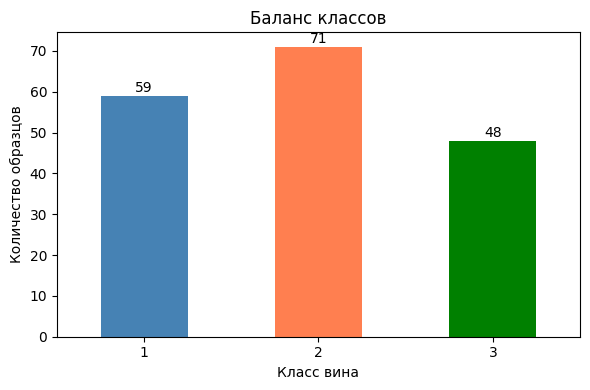

class
1    59
2    71
3    48
Name: count, dtype: int64


In [66]:
counts = data['class'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color=['steelblue', 'coral', 'green'])
plt.title('Баланс классов')
plt.xlabel('Класс вина')
plt.ylabel('Количество образцов')
plt.xticks(rotation=0)
for i, v in enumerate(counts):
    plt.text(i, v + 1, str(v), ha='center')
plt.tight_layout()
plt.show()

print(counts)


Удаление выбросов

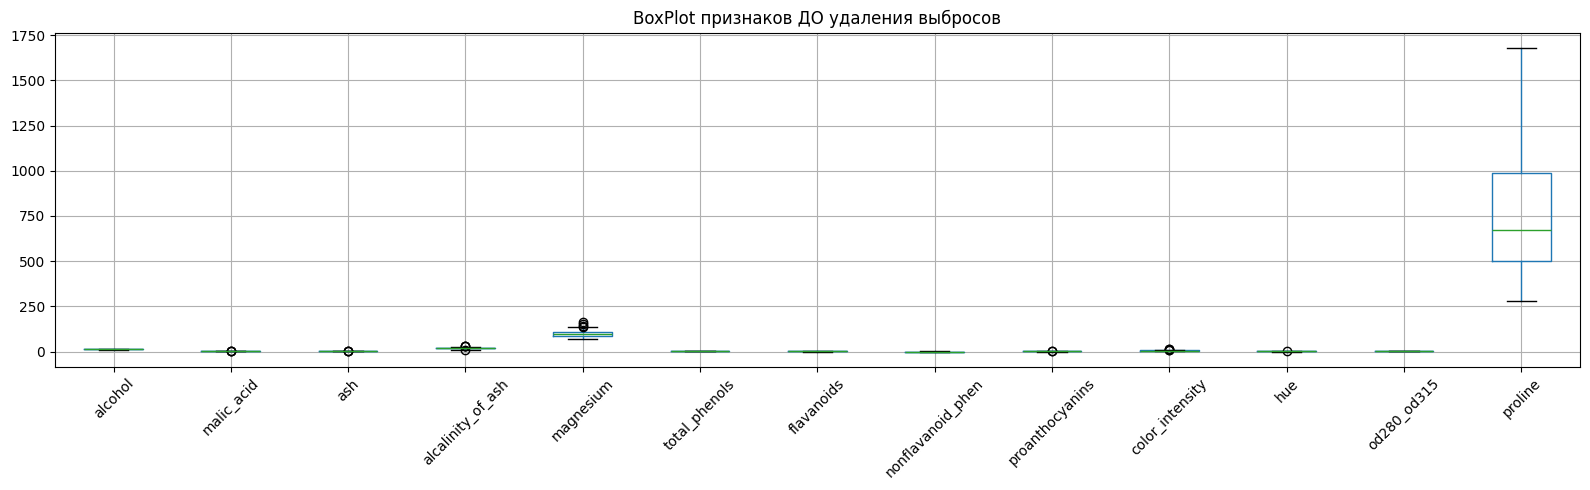

Размер ДО удаления выбросов: (178, 14)
Размер ПОСЛЕ удаления выбросов: (174, 14)


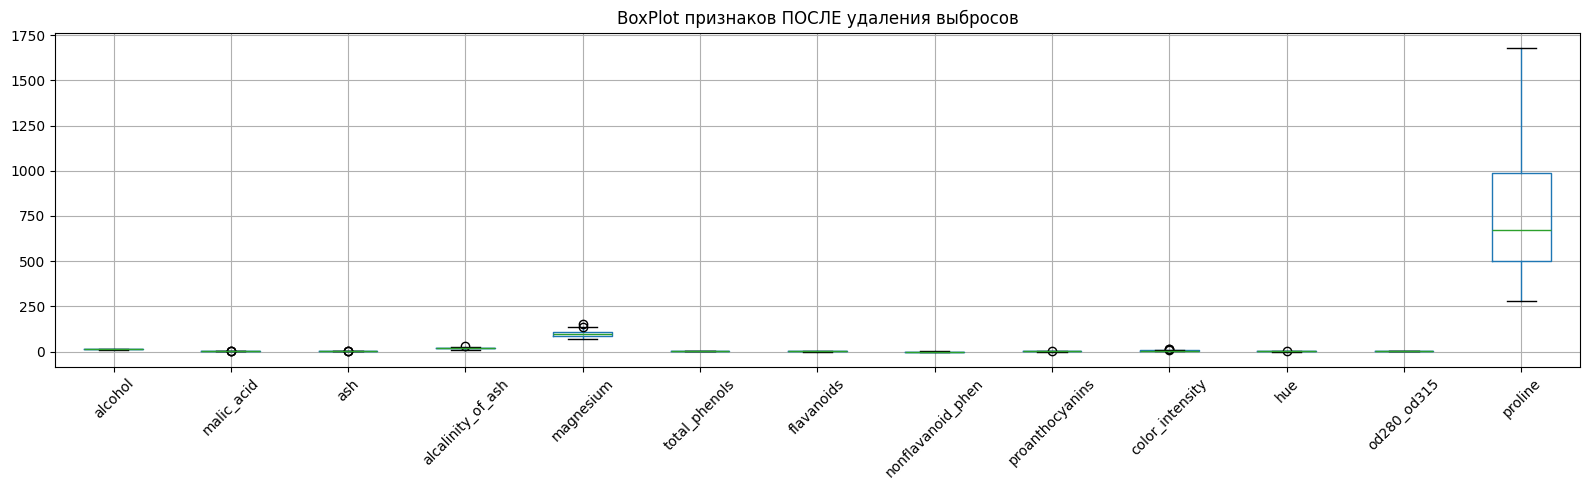

In [67]:
feature_cols = [c for c in data.columns if c != 'class']

# BoxPlot ДО
plt.figure(figsize=(16, 5))
data[feature_cols].boxplot()
plt.title('BoxPlot признаков ДО удаления выбросов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

def remove_outliers_iqr_soft(df, cols, min_violations=2):
    """
    Удаляет строку только если она является выбросом
    одновременно по min_violations и более признакам.
    Это мягче, чем удалять строку при выбросе хотя бы в одном.
    """
    df_clean = df.copy()
    outlier_mask = pd.DataFrame(False, index=df.index, columns=cols)
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_mask[col] = (df_clean[col] < lower) | (df_clean[col] > upper)
    rows_to_drop = outlier_mask.sum(axis=1) >= min_violations
    return df_clean[~rows_to_drop]

print(f"Размер ДО удаления выбросов: {data.shape}")
data = remove_outliers_iqr_soft(data, feature_cols, min_violations=2)
print(f"Размер ПОСЛЕ удаления выбросов: {data.shape}")

# BoxPlot ПОСЛЕ
plt.figure(figsize=(16, 5))
data[feature_cols].boxplot()
plt.title('BoxPlot признаков ПОСЛЕ удаления выбросов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Проверка на пропущенные значения

In [68]:
print("Пропущенные значения ДО заполнения:")
print(data.isnull().sum())

imputer = SimpleImputer(strategy='median')
data[feature_cols] = imputer.fit_transform(data[feature_cols])

print("\nПропущенные значения ПОСЛЕ заполнения:")
print(data.isnull().sum())

Пропущенные значения ДО заполнения:
class                0
alcohol              0
malic_acid           0
ash                  0
alcalinity_of_ash    0
magnesium            0
total_phenols        0
flavanoids           0
nonflavanoid_phen    0
proanthocyanins      0
color_intensity      0
hue                  0
od280_od315          0
proline              0
dtype: int64

Пропущенные значения ПОСЛЕ заполнения:
class                0
alcohol              0
malic_acid           0
ash                  0
alcalinity_of_ash    0
magnesium            0
total_phenols        0
flavanoids           0
nonflavanoid_phen    0
proanthocyanins      0
color_intensity      0
hue                  0
od280_od315          0
proline              0
dtype: int64


Масштабирование. Выбираем MinMaxScaler (нормализация [0, 1]):
 Признаки имеют разные единицы и диапазоны (proline ~0–1500, alcohol ~11–14).
 KNN использует расстояния → единый масштаб критически важен.
 MinMaxScaler сохраняет форму распределения и не чувствителен к нормальности.

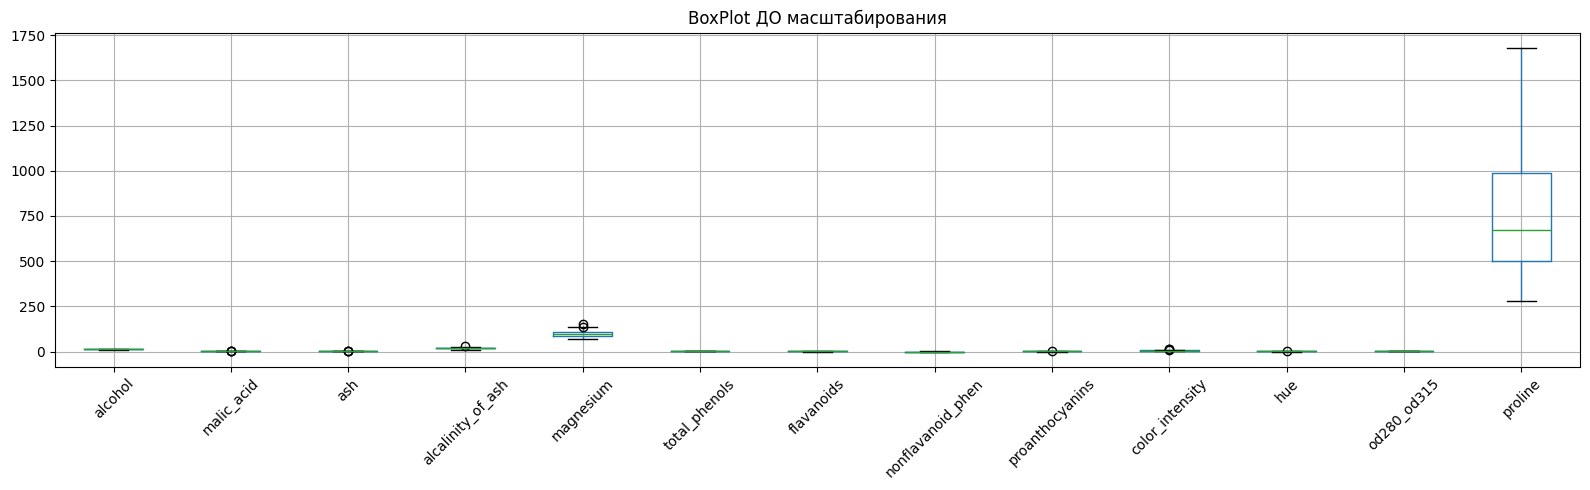

    alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0  0.842105    0.191700  0.480263           0.254335   0.703704   
1  0.571053    0.205534  0.289474           0.000000   0.370370   
2  0.560526    0.320158  0.638158           0.427746   0.382716   
3  0.878947    0.239130  0.526316           0.323699   0.530864   
4  0.581579    0.365613  0.769737           0.566474   0.592593   

   total_phenols  flavanoids  nonflavanoid_phen  proanthocyanins  \
0       0.627586    0.757660           0.283019         0.593060   
1       0.575862    0.674095           0.245283         0.274448   
2       0.627586    0.807799           0.320755         0.757098   
3       0.989655    0.877437           0.207547         0.558360   
4       0.627586    0.654596           0.490566         0.444795   

   color_intensity       hue  od280_od315   proline  
0         0.372014  0.455285     0.970696  0.561341  
1         0.264505  0.463415     0.780220  0.550642  
2         0.375427  0.4471

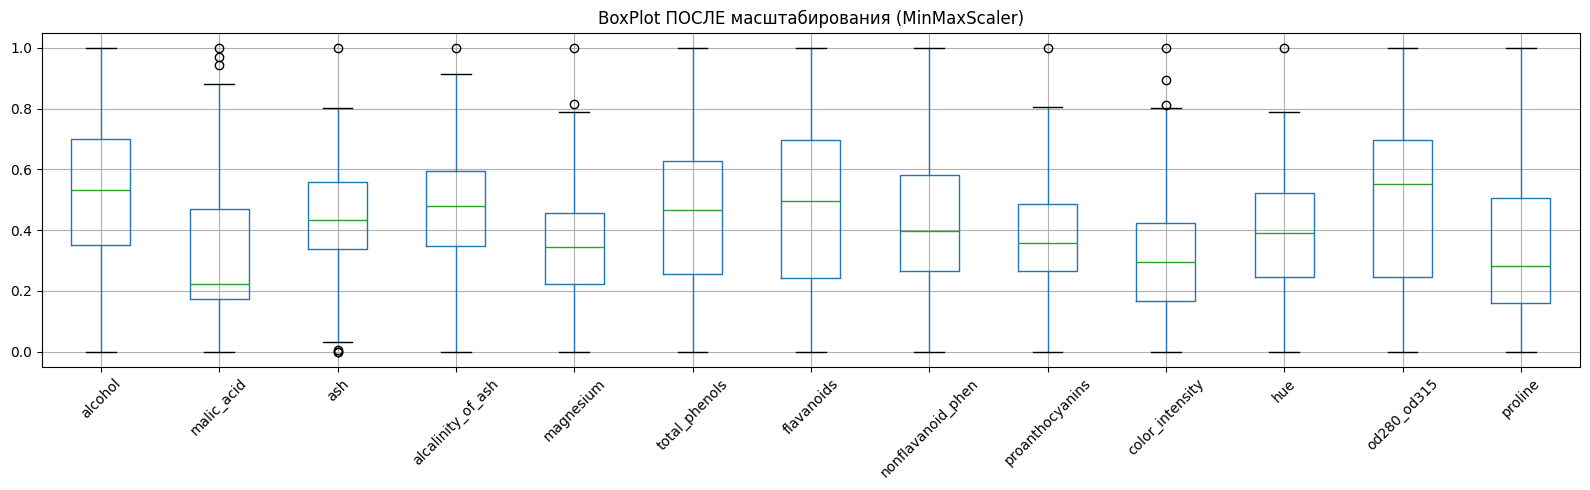

In [69]:
plt.figure(figsize=(16, 5))
data[feature_cols].boxplot()
plt.title('BoxPlot ДО масштабирования')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

scaler = MinMaxScaler()
data[feature_cols] = scaler.fit_transform(data[feature_cols])

print(data[feature_cols].head())

plt.figure(figsize=(16, 5))
data[feature_cols].boxplot()
plt.title('BoxPlot ПОСЛЕ масштабирования (MinMaxScaler)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Все 13 признаков в датасете Wine — числовые (continuous).
# Категориальных столбцов нет → замена не требуется.
# Категориальных признаков нет. Все признаки числовые
Шаг замены категориальных признаков не применяется

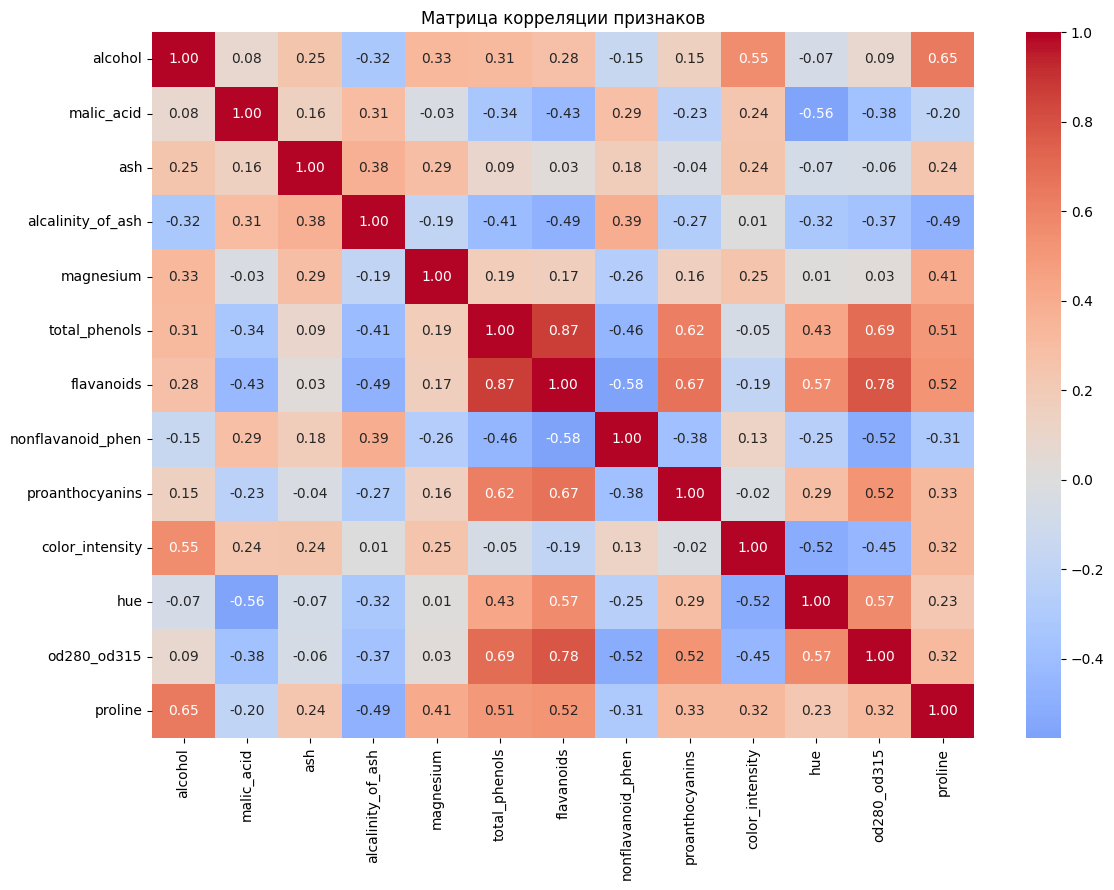

Количество сильных корреляций (|r| > 0.7) у каждого признака:
  flavanoids: 2
  total_phenols: 1
  od280_od315: 1
  alcohol: 0
  malic_acid: 0
  ash: 0
  alcalinity_of_ash: 0
  magnesium: 0
  nonflavanoid_phen: 0
  proanthocyanins: 0
  color_intensity: 0
  hue: 0
  proline: 0


In [70]:
corr = data[feature_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляции признаков')
plt.tight_layout()
plt.show()

threshold = 0.7
high_corr_count = {}
for col in feature_cols:
    count = (corr[col].abs() > threshold).sum() - 1
    high_corr_count[col] = count

print("Количество сильных корреляций (|r| > 0.7) у каждого признака:")
for k, v in sorted(high_corr_count.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v}")


# Вывод: наибольшее число высоких корреляций имеют признаки flavanoids, total_phenols, od280_od315.
Линейного классификатора в варианте 20 нет (классификаторы 1 и 4),
поэтому признаки с высокой корреляцией удалять не требуется.


Лучшие параметры для Дерева: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 5}


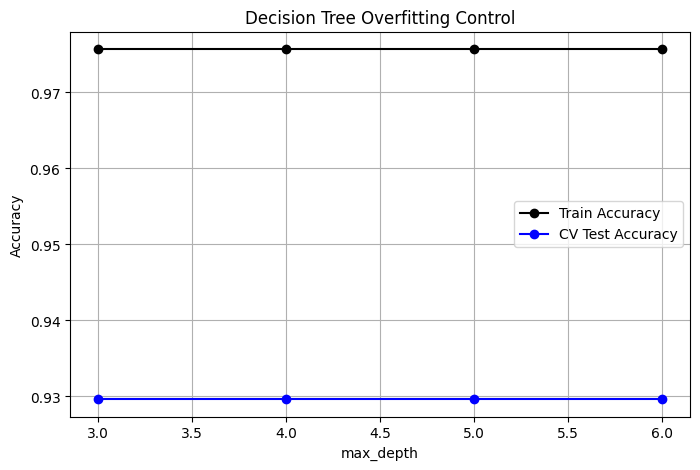

In [71]:
imputer = SimpleImputer(strategy='median')
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(imputer.fit_transform(X_train))
X_test_scaled = scaler.transform(imputer.transform(X_test))

dt_param_grid = {
    'max_depth': [3, 4, 5, 6],
    'min_samples_leaf': [3, 5, 8],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='accuracy',
    return_train_score=True
)

grid_dt.fit(X_train_scaled, y_train)
print("Лучшие параметры для Дерева:", grid_dt.best_params_)

results_dt = grid_dt.cv_results_
depths = dt_param_grid['max_depth']

train_scores_dt = [np.mean(results_dt['mean_train_score'][results_dt['param_max_depth'] == d]) for d in depths]
test_scores_dt = [np.mean(results_dt['mean_test_score'][results_dt['param_max_depth'] == d]) for d in depths]

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores_dt, label='Train Accuracy', marker='o', color='black')
plt.plot(depths, test_scores_dt, label='CV Test Accuracy', marker='o', color='blue')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Overfitting Control')
plt.legend()
plt.grid(True)
plt.show()

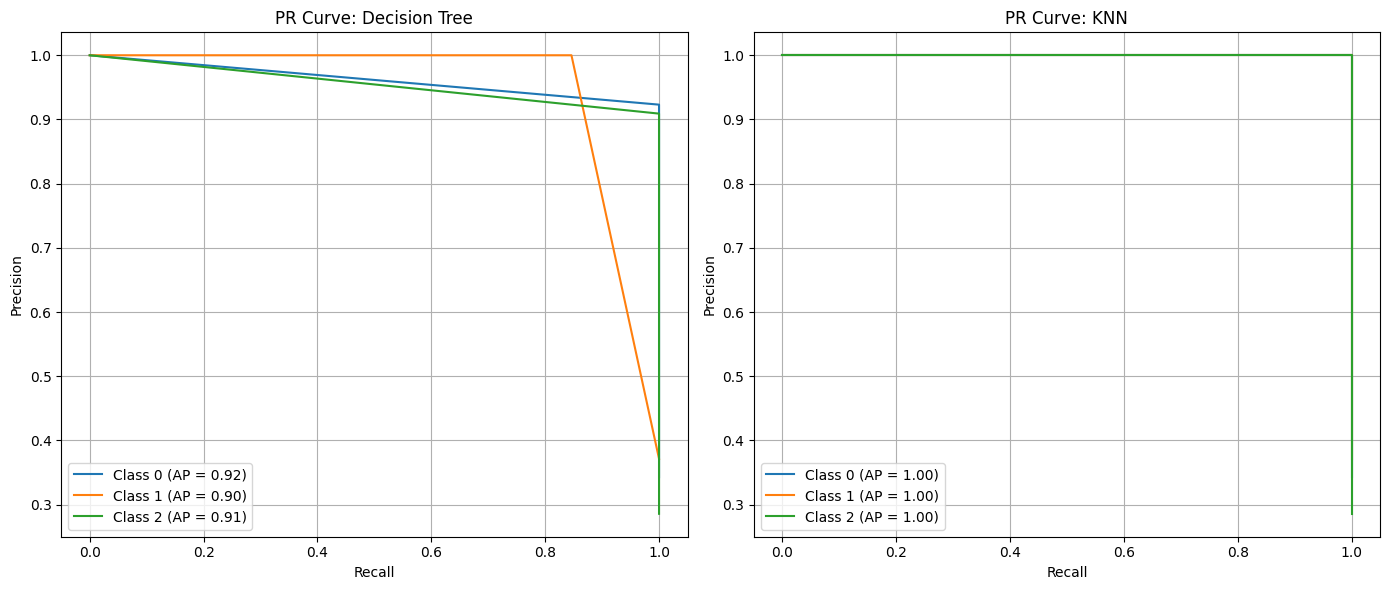

In [78]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

best_dt = grid_dt.best_estimator_
best_knn = grid_knn.best_estimator_

classes = best_dt.classes_
y_test_bin = label_binarize(y_test, classes=classes)

dt_probs = best_dt.predict_proba(X_test_scaled)
knn_probs = best_knn.predict_proba(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, class_label in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], dt_probs[:, i])
    ap = average_precision_score(y_test_bin[:, i], dt_probs[:, i])
    axes[0].plot(recall, precision, label=f'Class {class_label} (AP = {ap:.2f})')

axes[0].set_title('PR Curve: Decision Tree')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].legend(loc='best')
axes[0].grid(True)

for i, class_label in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], knn_probs[:, i])
    ap = average_precision_score(y_test_bin[:, i], knn_probs[:, i])
    axes[1].plot(recall, precision, label=f'Class {class_label} (AP = {ap:.2f})')

axes[1].set_title('PR Curve: KNN')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='best')
axes[1].grid(True)

plt.tight_layout()
plt.show()

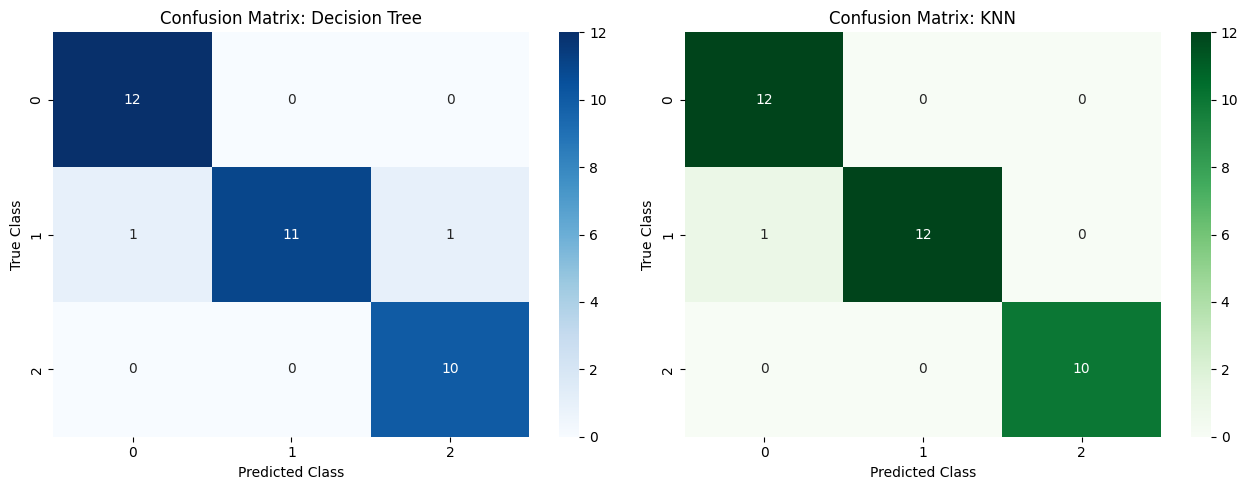

In [79]:
y_pred_dt = best_dt.predict(X_test_scaled)
y_pred_knn = best_knn.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('Confusion Matrix: Decision Tree')
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('True Class')

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title('Confusion Matrix: KNN')
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('True Class')

plt.tight_layout()
plt.show()